In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv('IMDB.csv', encoding='latin1')

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (50000, 2)

First 5 Rows:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [3]:
encoder = LabelEncoder()

df['sentiment'] = encoder.fit_transform(df['sentiment'])

In [4]:
print("\nSentiment Counts:")
print(df['sentiment'].value_counts())



Sentiment Counts:
sentiment
1    25000
0    25000
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'],
    df['sentiment'],
    test_size=0.2,
    random_state=42
)

In [6]:
vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size)

# Learn vocabulary
tokenizer.fit_on_texts(X_train)

# Convert text -> integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("\nExample Sequence:")
print(X_train_seq[0])



Example Sequence:
[197, 48, 10, 801, 2160, 534, 302, 1, 107, 1907, 2038, 4324, 6550, 2, 815, 4844, 12, 1, 227, 1, 6190, 79, 782, 53, 52, 22, 101, 4, 1, 27, 2009, 102, 36, 25, 34, 119, 1130, 12, 9, 6, 2366, 1190, 5, 454, 48, 552, 5, 92, 33, 23, 39, 916, 400, 15, 1, 166, 5, 2994, 24, 4359, 20, 3, 2945, 12, 45, 75, 221, 73, 126, 8, 81, 3155, 195, 20, 239, 2, 1, 447, 7, 7, 10, 205, 4982, 144, 21, 63, 27, 15, 74, 365, 302, 3, 19, 18, 9, 205, 26, 307, 12, 14, 1, 115, 439, 2, 14, 1, 1704, 615, 70, 424, 381, 10, 89, 118, 48, 112, 370, 33, 35, 18, 43, 10, 13, 92, 485, 6830, 15, 3, 364, 1182, 61, 8, 1, 470, 216, 1014, 5, 4160, 8, 3, 174, 4, 34, 440, 697, 623, 12, 3748, 237, 111, 848, 35, 170, 30, 219, 197, 1, 428, 367, 55, 3765, 3, 278, 7, 7, 157, 1707, 187, 6, 1, 727, 1935, 1, 1200, 4, 2946, 3749, 1828, 2, 147, 144, 3, 228, 4, 3, 207, 323, 2, 144, 1083, 16, 88, 4, 132, 2871, 8743, 18, 10, 153, 9253, 99, 4, 1, 4020, 302, 11, 17, 1001, 35, 1, 496, 492, 2619, 249, 71, 77, 107, 107, 698, 60, 86, 1

In [7]:
max_length = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("\nShape after Padding:")
print(X_train_pad.shape)


Shape after Padding:
(40000, 200)


In [8]:
model = Sequential([

    # Word Embedding Layer
    Embedding(
        input_dim=vocab_size,
        output_dim=64,
        input_length=max_length
    ),

    # Better than Flatten()
    GlobalAveragePooling1D(),

    # Hidden Layer 1
    Dense(64, activation='relu'),

    # Dropout prevents overfitting
    Dropout(0.5),

    # Hidden Layer 2
    Dense(32, activation='relu'),

    # Another Dropout
    Dropout(0.3),

    # Output Layer
    Dense(1, activation='sigmoid')
])


D:\ANACONDA\envs\lpdeeplearn\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [9]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [10]:
print("\nModel Summary:\n")
model.summary()


Model Summary:



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ ?                           │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)


In [12]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.6075 - loss: 0.6410 - val_accuracy: 0.8601 - val_loss: 0.3375
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8682 - loss: 0.3281 - val_accuracy: 0.8639 - val_loss: 0.3272
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8936 - loss: 0.2765 - val_accuracy: 0.8735 - val_loss: 0.3130
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9192 - loss: 0.2295 - val_accuracy: 0.8750 - val_loss: 0.3192
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9321 - loss: 0.2037 - val_accuracy: 0.8709 - val_loss: 0.3353


In [13]:
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8743 - loss: 0.3011

Test Loss: 0.30635866522789
Test Accuracy: 0.8726999759674072


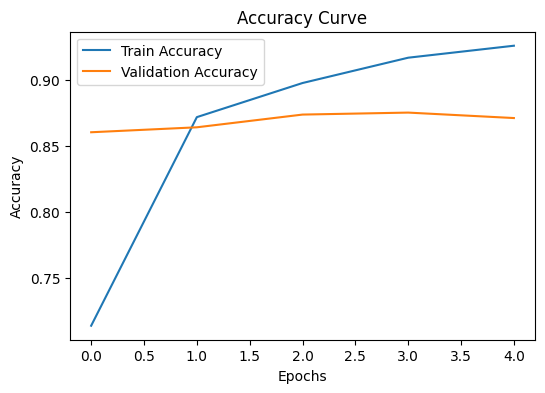

In [14]:
plt.figure(figsize=(6,4))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.legend()

plt.show()

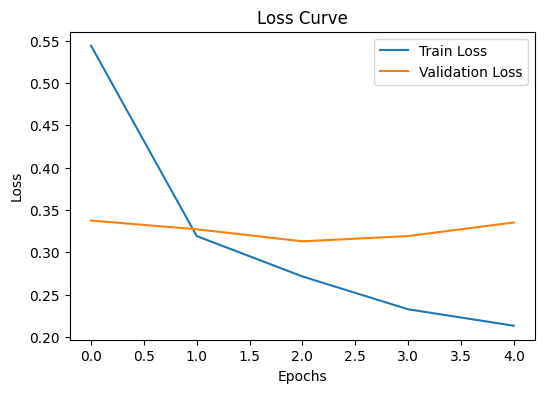

In [15]:
plt.figure(figsize=(6,4))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()

plt.show()



In [16]:
y_pred = (
    model.predict(X_test_pad) > 0.5
).astype("int32")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [17]:
print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=['Negative', 'Positive']
))



Classification Report:

              precision    recall  f1-score   support

    Negative       0.91      0.82      0.87      4961
    Positive       0.84      0.92      0.88      5039

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



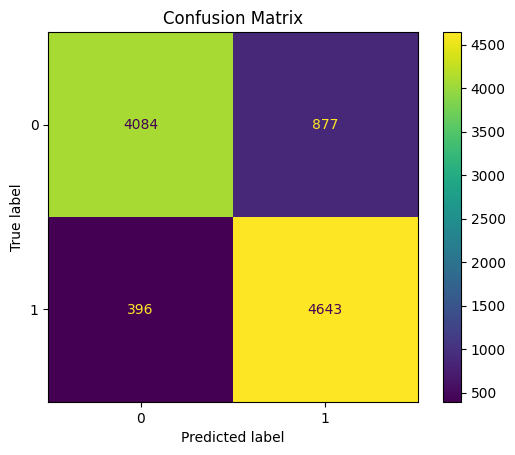

In [18]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()